<a href="https://colab.research.google.com/github/mfaiz23/Churn-Prediction-OCTE/blob/main/04_evaluation_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 NOTEBOOK 04 — EVALUASI KOMPREHENSIF & VISUALISASI
**Eksperimen 4: SMOTE Before Split + OCTE (Optimal Causal Decision Trees Ensemble)**

---
## Deskripsi
Notebook ini adalah **tahap akhir** dari alur penelitian. Semua hasil dari notebook sebelumnya dikumpulkan untuk evaluasi komprehensif:

**A. Evaluasi Klasifikasi:**
- Confusion Matrix berlabel untuk kedua model
- ROC Curve komparatif
- Dashboard metrik (Accuracy, Precision, Recall, F1, AUC-ROC)

**B. Evaluasi Kausal (CATE Analysis):**
- Distribusi CATE (histogram + KDE)
- MSE & RMSE dari estimasi CATE
- Analisis heterogenitas efek treatment per kelompok
- Boxplot CATE berdasarkan segmen pelanggan

**C. Insights & Business Recommendations:**
- Visualisasi feature importance
- Segmentasi pelanggan berdasarkan CATE

## Prasyarat
> ✅ Notebook 03 harus sudah dijalankan. File prediksi dan model tersedia di Google Drive.

---
## Cell 1 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/last_experiment'
print(f'✅ Google Drive mounted. Base path: {BASE_PATH}')

Mounted at /content/drive
✅ Google Drive mounted. Base path: /content/drive/MyDrive/last_experiment


---
## Cell 2 — Import Library

In [ ]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)

# Style global untuk semua plot
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'font.family': 'DejaVu Sans'
})
sns.set_style('whitegrid')

print('✅ Library berhasil di-import.')

✅ Library berhasil di-import.


In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

class ManualOCTE:
    """
    Optimal Causal Decision Trees Ensemble (OCTE)
    Implementasi berdasarkan: Younas et al. (2022) IEEE Access.
    DOI: 10.1109/ACCESS.2022.3146406

    Parameters
    ----------
    n_trees : int
        B — jumlah pohon kausal awal yang ditumbuhkan
    top_m : int
        M — jumlah pohon terbaik yang dipilih ke ensemble final
    max_depth : int
        Kedalaman maksimum setiap decision tree
    random_state : int
        Seed untuk reprodusibilitas
    """

    def __init__(self, n_trees=150, top_m=40, max_depth=8, random_state=42):
        self.B = n_trees
        self.M = top_m
        self.max_depth = max_depth
        self.random_state = random_state
        self.selected_trees = []
        self.oob_errors_selected = []
        self.training_log = []

    def fit(self, X_data, y_data, w_data):
        """
        Langkah 1–8 dari Algorithm 1 (paper):
        Tumbuhkan B pohon, hitung OOB SE, pilih Top-M terbaik.
        """
        np.random.seed(self.random_state)
        all_trees = []
        oob_errors = []
        n_samples = len(X_data)

        X_arr = np.array(X_data, dtype=float)
        y_arr = np.array(y_data, dtype=float)
        w_arr = np.array(w_data, dtype=float)

        print(f'🚀 Memulai konstruksi {self.B} pohon kausal awal...')
        print(f'   Konfigurasi: B={self.B}, M={self.M}, max_depth={self.max_depth}')

        for b in range(self.B):
            # Step 1: Bootstrap sub-sampling (bagging)
            boot_idx = np.random.choice(n_samples, size=n_samples, replace=True)
            oob_mask = np.ones(n_samples, dtype=bool)
            oob_mask[np.unique(boot_idx)] = False
            oob_idx = np.where(oob_mask)[0]

            X_b, y_b, w_b = X_arr[boot_idx], y_arr[boot_idx], w_arr[boot_idx]

            # Step 2: Gabungkan X dan W sebagai input tree
            X_tree_input = np.column_stack((X_b, w_b))

            # Step 3: Tumbuhkan causal decision tree
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                random_state=self.random_state + b
            )
            tree.fit(X_tree_input, y_b)

            # Step 4 & 5: Hitung OOB Standard Error
            if len(oob_idx) > 0:
                X_oob_input = np.column_stack((X_arr[oob_idx], w_arr[oob_idx]))
                oob_preds = tree.predict(X_oob_input)
                # MSE sebagai proxy Standard Error (sesuai paper)
                mse_oob = np.mean((y_arr[oob_idx] - oob_preds) ** 2)
            else:
                mse_oob = float('inf')

            all_trees.append(tree)
            oob_errors.append(mse_oob)

        # Step 9–10: Ranking & Seleksi Top-M
        top_indices = np.argsort(oob_errors)[:self.M]
        self.selected_trees = [all_trees[i] for i in top_indices]
        self.oob_errors_selected = [oob_errors[i] for i in top_indices]

        # Log training
        self.training_log = {
            'n_trees_grown': self.B,
            'n_trees_selected': self.M,
            'avg_oob_mse_all': np.mean([e for e in oob_errors if e != float('inf')]),
            'avg_oob_mse_selected': np.mean(self.oob_errors_selected),
            'best_oob_mse': min(self.oob_errors_selected),
            'worst_oob_mse': max(self.oob_errors_selected)
        }

    def predict_proba(self, X_data):
        """
        Prediksi probabilitas pada kondisi kontrol (W=0).
        Rata-rata prediksi dari M pohon terpilih.
        """
        X_arr = np.array(X_data, dtype=float)
        X_control = np.column_stack((X_arr, np.zeros(len(X_arr))))

        accumulated = np.zeros(len(X_arr))
        for tree in self.selected_trees:
            accumulated += tree.predict(X_control)

        probs = accumulated / self.M
        # Clip ke [0, 1] untuk memastikan valid sebagai probabilitas
        return np.clip(probs, 0, 1)

    def predict_class(self, X_data, threshold=0.5):
        """Prediksi kelas biner dengan threshold tertentu."""
        probs = self.predict_proba(X_data)
        return (probs >= threshold).astype(int)

    def estimate_cate(self, X_data):
        """
        Estimasi Conditional Average Treatment Effect (CATE):
        CATE_i = E[Y | X_i, W=1] - E[Y | X_i, W=0]
        """
        X_arr = np.array(X_data, dtype=float)
        X_treat   = np.column_stack((X_arr, np.ones(len(X_arr))))
        X_control = np.column_stack((X_arr, np.zeros(len(X_arr))))

        cate_accum = np.zeros(len(X_arr))
        for tree in self.selected_trees:
            y1_hat = tree.predict(X_treat)
            y0_hat = tree.predict(X_control)
            cate_accum += (y1_hat - y0_hat)

        return cate_accum / self.M

---
## Cell 3 — Load Semua Hasil dari Google Drive

In [ ]:
PROC_PATH = f'{BASE_PATH}/data/processed'
RES_PATH  = f'{BASE_PATH}/results'

# Load data uji
X_test   = pd.read_csv(f'{PROC_PATH}/X_test_selected.csv')
y_test   = pd.read_csv(f'{PROC_PATH}/y_test.csv')['churn value']
y_train  = pd.read_csv(f'{PROC_PATH}/y_train.csv')['churn value']
X_train  = pd.read_csv(f'{PROC_PATH}/X_train_selected.csv')

# Load prediksi hasil Notebook 03
preds_df = pd.read_csv(f'{RES_PATH}/predictions/octe_predictions.csv')

# Load metrik
metrics_df   = pd.read_csv(f'{RES_PATH}/metrics/classification_performance.csv')
causal_df    = pd.read_csv(f'{RES_PATH}/metrics/causal_metrics_octe.csv')
ig_df        = pd.read_csv(f'{RES_PATH}/metrics/information_gain_ranking.csv')

# Load model
with open(f'{RES_PATH}/models/octe_manual_model.pkl', 'rb') as f:
    octe_model = pickle.load(f)
with open(f'{RES_PATH}/models/rf_baseline_model.pkl', 'rb') as f:
    rf_model = pickle.load(f)

# Extract prediksi
rf_preds    = preds_df['RF_Pred_Class'].values
rf_probs    = preds_df['RF_Prob'].values
octe_preds  = preds_df['OCTE_Pred_Class'].values
octe_probs  = preds_df['OCTE_Prob'].values
cate_est    = preds_df['CATE_Estimate'].values
W_test      = preds_df['W_Treatment'].values

print('✅ Semua artefak berhasil dimuat.')
print(f'   Prediksi       : {len(preds_df):,} observasi')
print(f'   Model OCTE     : {octe_model.M} pohon terpilih dari {octe_model.B}')
print(f'\n📋 Preview prediksi:')
display(preds_df.head())

✅ Semua artefak berhasil dimuat.
   Prediksi       : 2,070 observasi
   Model OCTE     : 40 pohon terpilih dari 150

📋 Preview prediksi:


,Actual_Churn,W_Treatment,RF_Pred_Class,RF_Prob,OCTE_Pred_Class,OCTE_Prob,CATE_Estimate
0,0,1.000000,0,0.080507,0,0.111224,-0.103176
1,1,0.000000,1,0.992607,1,1.000000,0.000000
2,1,0.523539,1,0.767829,1,0.636832,-0.136731
3,0,1.000000,0,0.098591,0,0.098206,-0.093034
4,0,0.000000,0,0.403577,0,0.356757,-0.174929


---
# BAGIAN A — EVALUASI KLASIFIKASI

---
## Cell 4 — Confusion Matrix Berlabel: Kedua Model
Confusion Matrix menampilkan breakdown prediksi benar/salah untuk setiap kelas.

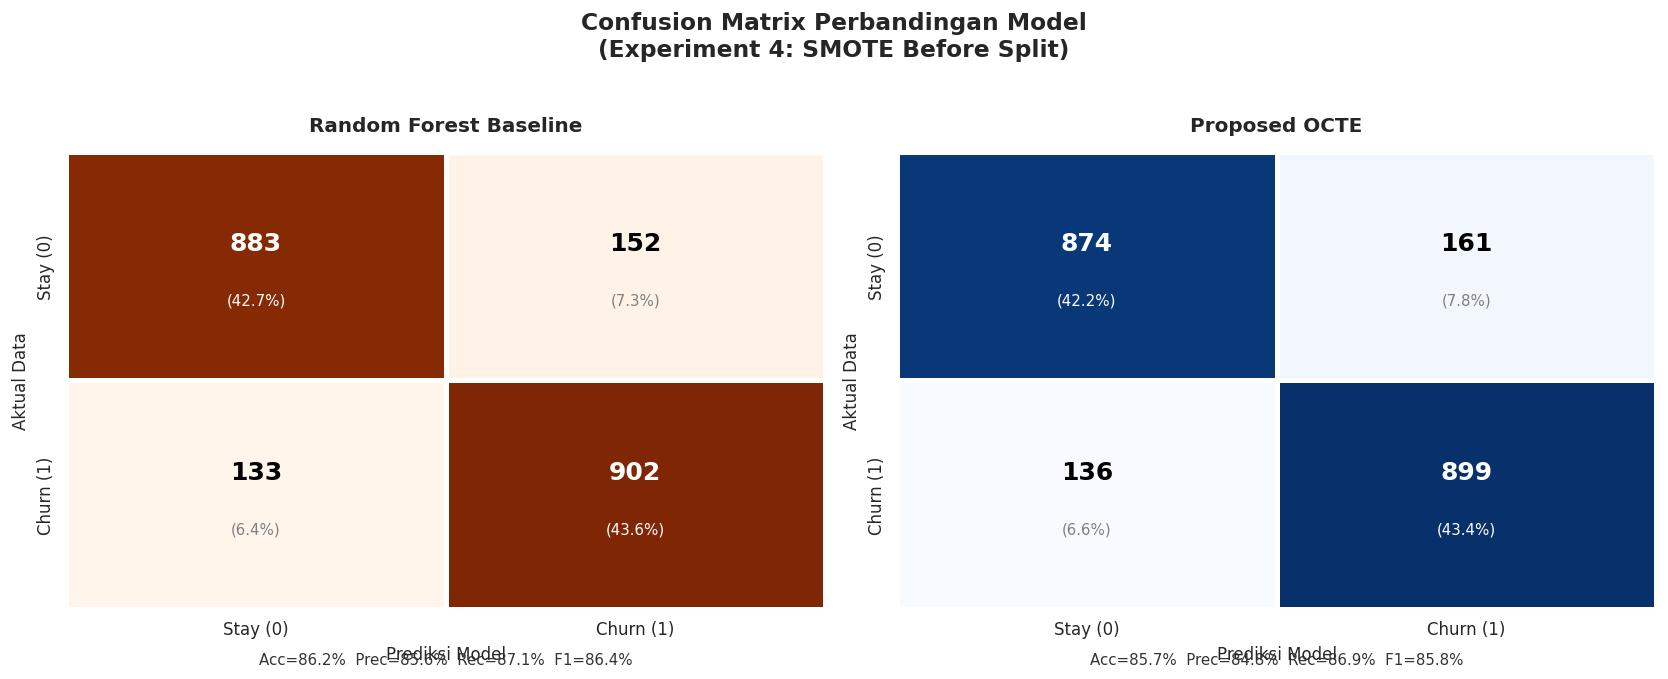

💾 Disimpan: /content/drive/MyDrive/last_experiment/figures/classification/confusion_matrix_comparison.png


In [ ]:
def plot_confusion_matrix_labeled(cm, ax, title, cmap):
    """Plot confusion matrix dengan label lengkap dan metrik per-kelas."""
    labels = ['Stay (0)', 'Churn (1)']
    total = cm.sum()
    tn, fp, fn, tp = cm.ravel()

    # Heatmap
    sns.heatmap(cm, annot=False, cmap=cmap, ax=ax, cbar=False,
                xticklabels=labels, yticklabels=labels,
                linewidths=2, linecolor='white')

    # Annotasi tiap cell
    for i in range(2):
        for j in range(2):
            val = cm[i, j]
            pct = val / total * 100
            ax.text(j + 0.5, i + 0.4, f'{val:,}', ha='center', va='center',
                    fontsize=15, fontweight='bold',
                    color='white' if val > cm.max()*0.6 else 'black')
            ax.text(j + 0.5, i + 0.65, f'({pct:.1f}%)', ha='center', va='center',
                    fontsize=9, color='white' if val > cm.max()*0.6 else 'gray')

    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('Prediksi Model', fontsize=10)
    ax.set_ylabel('Aktual Data', fontsize=10)

    # Tambahkan ringkasan metrik
    acc = (tp + tn) / total
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    summary = f'Acc={acc*100:.1f}%  Prec={prec*100:.1f}%  Rec={rec*100:.1f}%  F1={f1*100:.1f}%'
    ax.text(0.5, -0.12, summary, ha='center', transform=ax.transAxes, fontsize=9, color='#333333')


cm_rf   = confusion_matrix(y_test, rf_preds)
cm_octe = confusion_matrix(y_test, octe_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Confusion Matrix Perbandingan Model\n(Experiment 4: SMOTE Before Split)',
             fontsize=14, fontweight='bold', y=1.03)

plot_confusion_matrix_labeled(cm_rf,   axes[0], 'Random Forest Baseline', 'Oranges')
plot_confusion_matrix_labeled(cm_octe, axes[1], 'Proposed OCTE',          'Blues')

plt.tight_layout()
FIG1 = f'{BASE_PATH}/figures/classification/confusion_matrix_comparison.png'
plt.savefig(FIG1, dpi=300, bbox_inches='tight')
plt.show()
print(f'💾 Disimpan: {FIG1}')

---
## Cell 5 — ROC Curve Komparatif

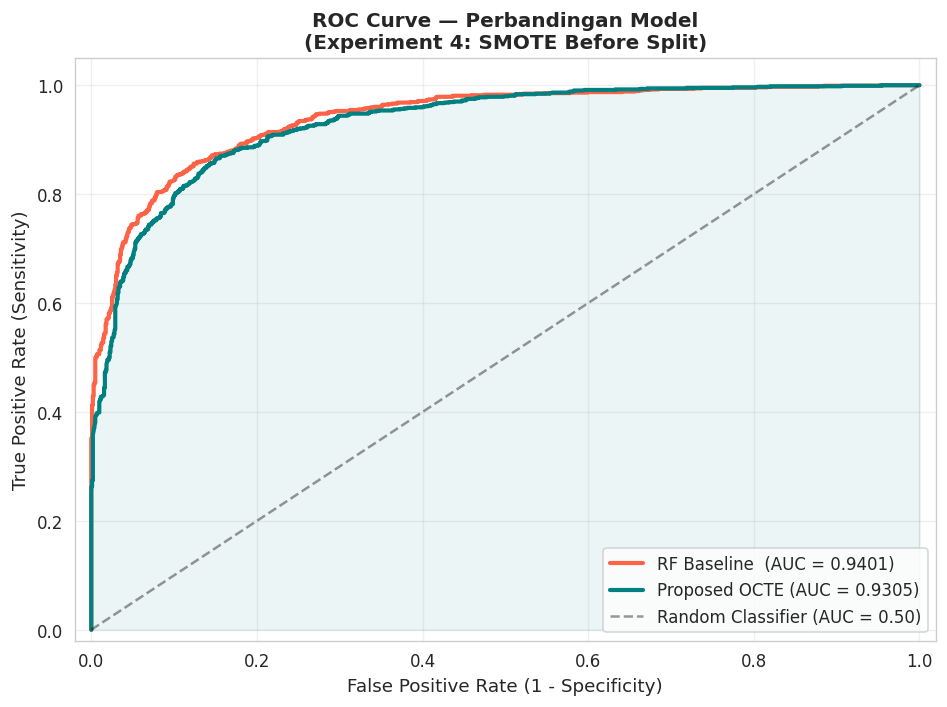

💾 Disimpan: /content/drive/MyDrive/last_experiment/figures/classification/roc_curve_comparison.png


In [ ]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_oc, tpr_oc, _ = roc_curve(y_test, octe_probs)

auc_rf   = roc_auc_score(y_test, rf_probs)
auc_octe = roc_auc_score(y_test, octe_probs)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr_rf, tpr_rf, color='tomato', lw=2.5, label=f'RF Baseline  (AUC = {auc_rf:.4f})')
ax.plot(fpr_oc, tpr_oc, color='teal',   lw=2.5, label=f'Proposed OCTE (AUC = {auc_octe:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random Classifier (AUC = 0.50)')

# Shade area under OCTE curve
ax.fill_between(fpr_oc, tpr_oc, alpha=0.08, color='teal')

ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
ax.set_title('ROC Curve — Perbandingan Model\n(Experiment 4: SMOTE Before Split)', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
FIG2 = f'{BASE_PATH}/figures/classification/roc_curve_comparison.png'
plt.savefig(FIG2, dpi=300, bbox_inches='tight')
plt.show()
print(f'💾 Disimpan: {FIG2}')

---
## Cell 6 — Panel Evaluasi Lengkap (3 Panel)
Visualisasi komprehensif dalam satu gambar: ROC Curve + dua Confusion Matrix.

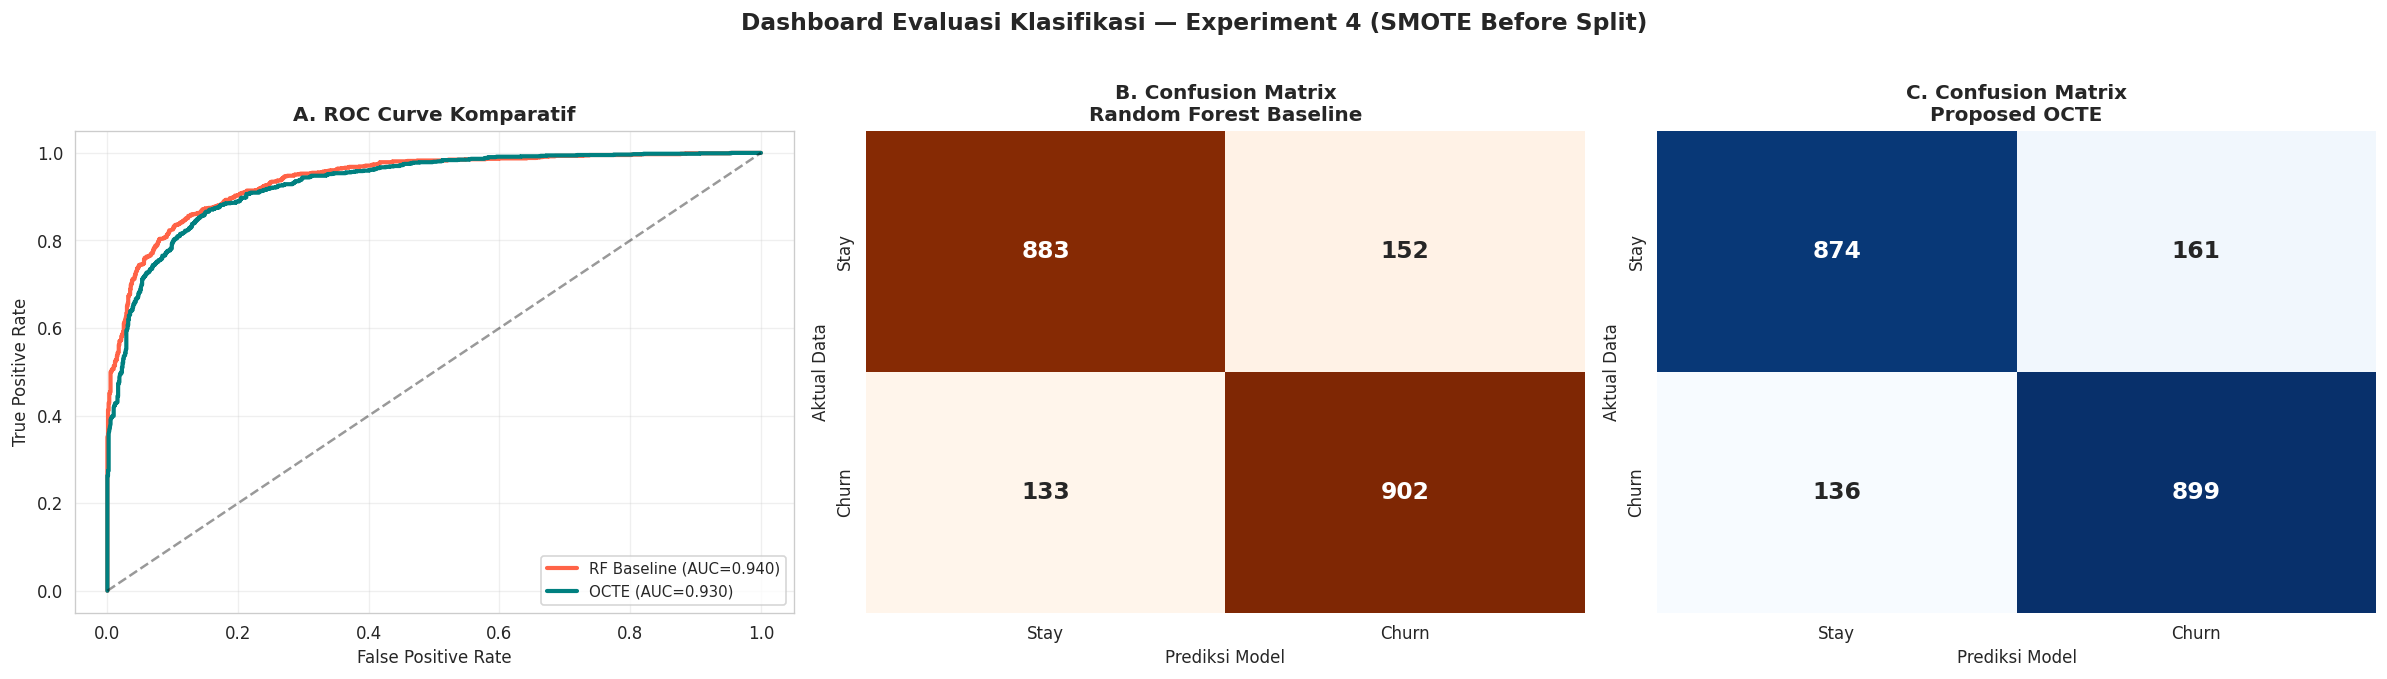

💾 Disimpan: /content/drive/MyDrive/last_experiment/figures/classification/model_evaluation.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
fig.suptitle('Dashboard Evaluasi Klasifikasi — Experiment 4 (SMOTE Before Split)',
             fontsize=14, fontweight='bold', y=1.02)

# Panel A: ROC Curve
axes[0].plot(fpr_rf, tpr_rf, color='tomato', lw=2.5, label=f'RF Baseline (AUC={auc_rf:.3f})')
axes[0].plot(fpr_oc, tpr_oc, color='teal',   lw=2.5, label=f'OCTE (AUC={auc_octe:.3f})')
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_title('A. ROC Curve Komparatif', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Panel B: Confusion Matrix RF
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[1],
            xticklabels=['Stay','Churn'], yticklabels=['Stay','Churn'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[1].set_title('B. Confusion Matrix\nRandom Forest Baseline', fontweight='bold')
axes[1].set_xlabel('Prediksi Model')
axes[1].set_ylabel('Aktual Data')

# Panel C: Confusion Matrix OCTE
sns.heatmap(cm_octe, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[2],
            xticklabels=['Stay','Churn'], yticklabels=['Stay','Churn'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[2].set_title('C. Confusion Matrix\nProposed OCTE', fontweight='bold')
axes[2].set_xlabel('Prediksi Model')
axes[2].set_ylabel('Aktual Data')

plt.tight_layout()
FIG3 = f'{BASE_PATH}/figures/classification/model_evaluation.png'
plt.savefig(FIG3, dpi=300, bbox_inches='tight')
plt.show()
print(f'💾 Disimpan: {FIG3}')

---
## Cell 7 — Classification Report Lengkap

In [ ]:
print('='*65)
print('  📊 CLASSIFICATION REPORT — RANDOM FOREST BASELINE')
print('='*65)
print(classification_report(y_test, rf_preds, target_names=['Stay (0)', 'Churn (1)']))

print('='*65)
print('  📊 CLASSIFICATION REPORT — PROPOSED OCTE')
print('='*65)
print(classification_report(y_test, octe_preds, target_names=['Stay (0)', 'Churn (1)']))

# Ringkasan perbandingan
print('='*65)
print('  📊 RINGKASAN METRIK PERBANDINGAN')
print('='*65)
display(metrics_df)

  📊 CLASSIFICATION REPORT — RANDOM FOREST BASELINE
              precision    recall  f1-score   support

    Stay (0)       0.87      0.85      0.86      1035
   Churn (1)       0.86      0.87      0.86      1035

    accuracy                           0.86      2070
   macro avg       0.86      0.86      0.86      2070
weighted avg       0.86      0.86      0.86      2070

  📊 CLASSIFICATION REPORT — PROPOSED OCTE
              precision    recall  f1-score   support

    Stay (0)       0.87      0.84      0.85      1035
   Churn (1)       0.85      0.87      0.86      1035

    accuracy                           0.86      2070
   macro avg       0.86      0.86      0.86      2070
weighted avg       0.86      0.86      0.86      2070

  📊 RINGKASAN METRIK PERBANDINGAN


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Random Forest Baseline,86.23%,85.58%,87.15%,86.36%,94.01%
1,Proposed OCTE,85.65%,84.81%,86.86%,85.82%,93.05%


---

## Cell 7a — Confusion Matrix Berlabel (Training Data)
Confusion Matrix menampilkan breakdown prediksi benar/salah untuk setiap kelas pada data training.

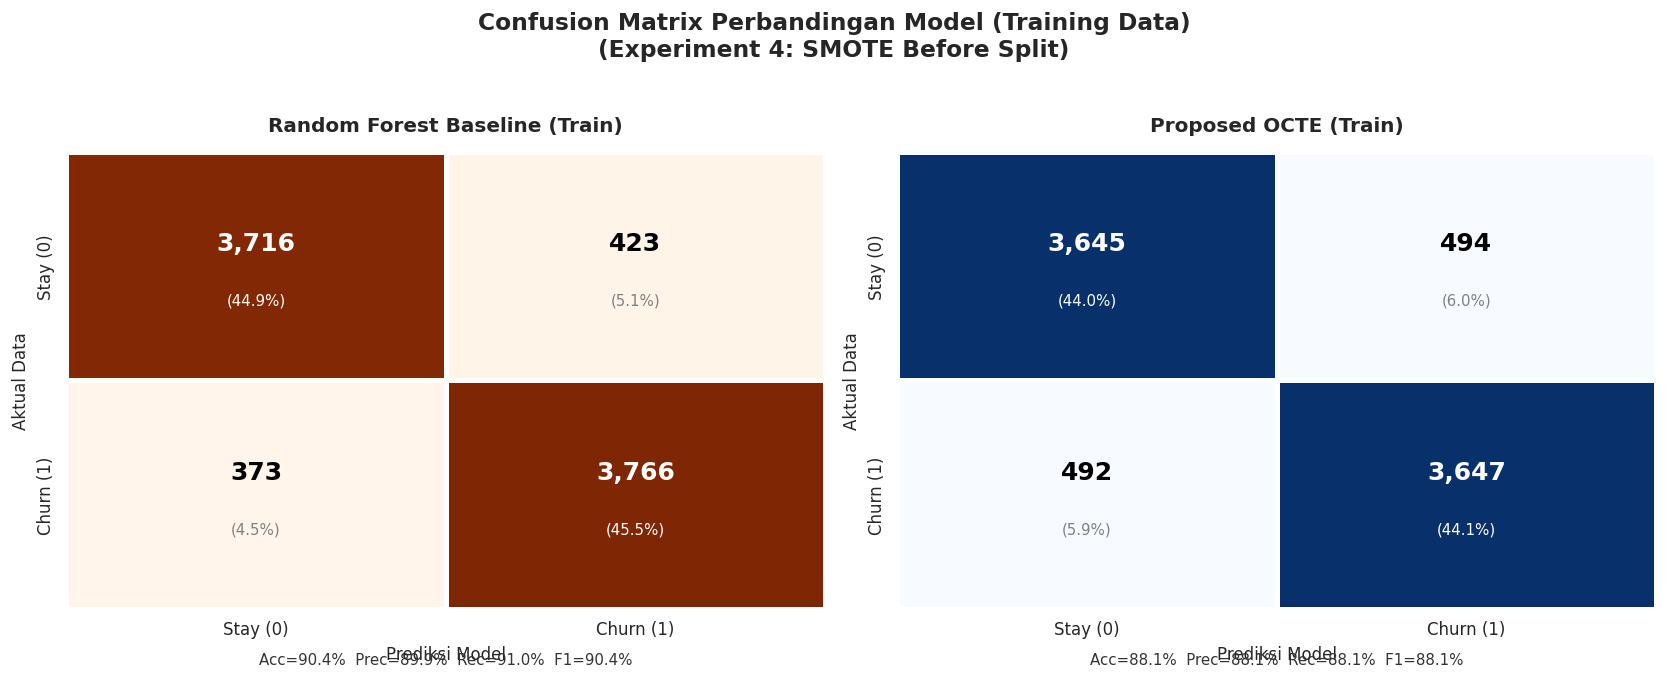

💾 Disimpan: /content/drive/MyDrive/last_experiment/figures/classification/confusion_matrix_comparison_train.png


In [ ]:
rf_preds_train = rf_model.predict(X_train.drop(columns=['treatment_w']))
octe_preds_train = octe_model.predict_class(X_train.drop(columns=['treatment_w']))

cm_rf_train   = confusion_matrix(y_train, rf_preds_train)
cm_octe_train = confusion_matrix(y_train, octe_preds_train)

fig_train, axes_train = plt.subplots(1, 2, figsize=(14, 5.5))
fig_train.suptitle('Confusion Matrix Perbandingan Model (Training Data)\n(Experiment 4: SMOTE Before Split)',
             fontsize=14, fontweight='bold', y=1.03)

plot_confusion_matrix_labeled(cm_rf_train,   axes_train[0], 'Random Forest Baseline (Train)', 'Oranges')
plot_confusion_matrix_labeled(cm_octe_train, axes_train[1], 'Proposed OCTE (Train)',          'Blues')

plt.tight_layout()
FIG1_TRAIN = f'{BASE_PATH}/figures/classification/confusion_matrix_comparison_train.png'
plt.savefig(FIG1_TRAIN, dpi=300, bbox_inches='tight')
plt.show()
print(f'💾 Disimpan: {FIG1_TRAIN}')

---

## Cell 7b — Classification Report Lengkap (Training Data)

In [ ]:
print('='*65)
print('  📊 CLASSIFICATION REPORT — RANDOM FOREST BASELINE (TRAIN DATA)')
print('='*65)
print(classification_report(y_train, rf_preds_train, target_names=['Stay (0)', 'Churn (1)']))

print('='*65)
print('  📊 CLASSIFICATION REPORT — PROPOSED OCTE (TRAIN DATA)')
print('='*65)
print(classification_report(y_train, octe_preds_train, target_names=['Stay (0)', 'Churn (1)']))

  📊 CLASSIFICATION REPORT — RANDOM FOREST BASELINE (TRAIN DATA)
              precision    recall  f1-score   support

    Stay (0)       0.91      0.90      0.90      4139
   Churn (1)       0.90      0.91      0.90      4139

    accuracy                           0.90      8278
   macro avg       0.90      0.90      0.90      8278
weighted avg       0.90      0.90      0.90      8278

  📊 CLASSIFICATION REPORT — PROPOSED OCTE (TRAIN DATA)
              precision    recall  f1-score   support

    Stay (0)       0.88      0.88      0.88      4139
   Churn (1)       0.88      0.88      0.88      4139

    accuracy                           0.88      8278
   macro avg       0.88      0.88      0.88      8278
weighted avg       0.88      0.88      0.88      8278



---
# BAGIAN B — EVALUASI KAUSAL (CATE ANALYSIS)

---
## Cell 8 — Distribusi CATE (Histogram + KDE)
Distribusi CATE menunjukkan **heterogenitas efek treatment** — seberapa berbeda dampak kontrak Two Year bagi tiap individu pelanggan.

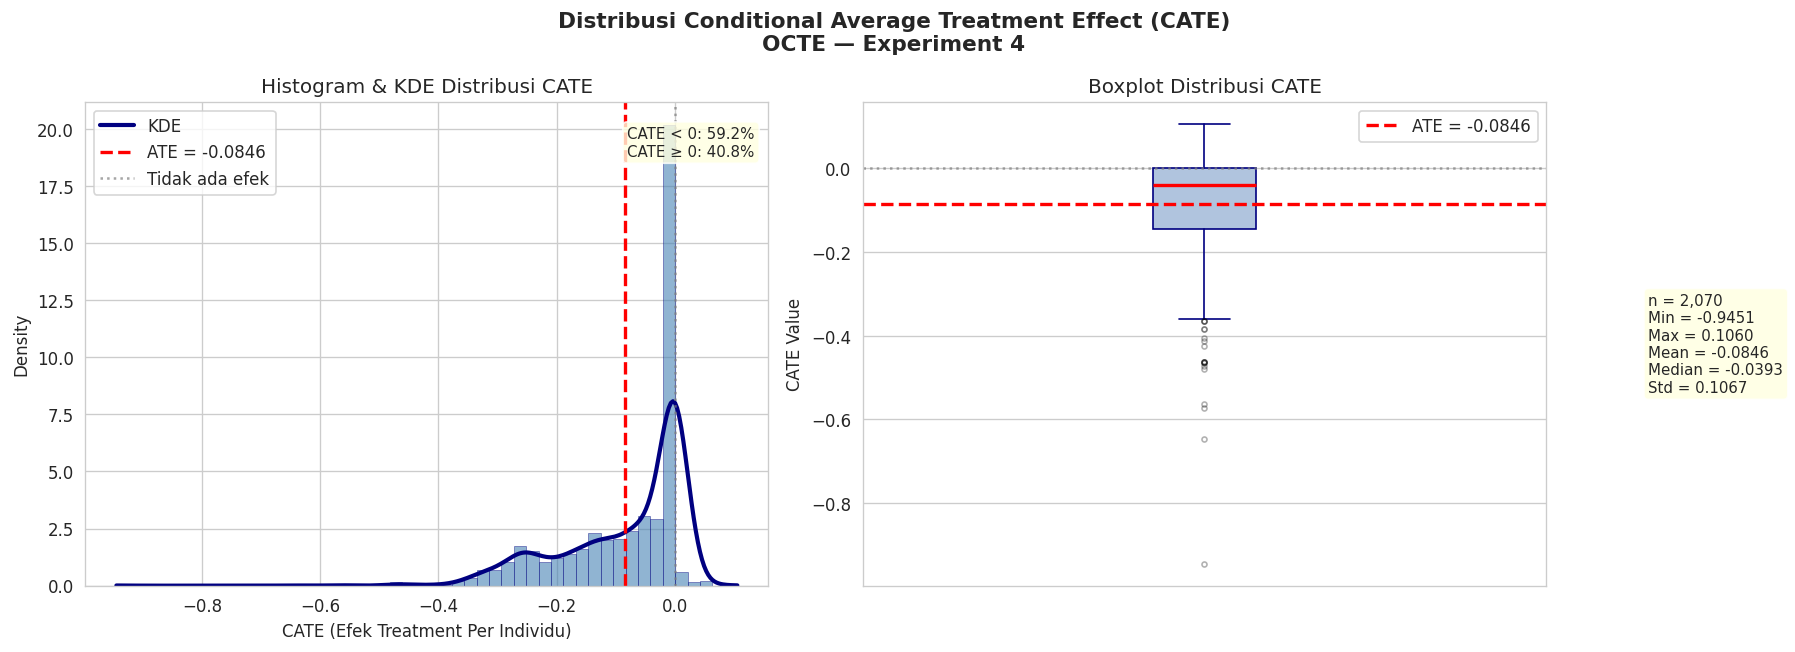

💾 Disimpan: /content/drive/MyDrive/last_experiment/figures/causal/cate_distribution.png

💡 Interpretasi: ATE = -0.0846
   → Kontrak Two Year rata-rata MENURUNKAN probabilitas churn sebesar 8.46%


In [ ]:
ate = cate_est.mean()
pct_negative = (cate_est < 0).mean() * 100
pct_positive = (cate_est >= 0).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Distribusi Conditional Average Treatment Effect (CATE)\nOCTE — Experiment 4',
             fontsize=13, fontweight='bold')

# Panel kiri: Histogram + KDE
axes[0].hist(cate_est, bins=50, color='steelblue', alpha=0.6,
             edgecolor='navy', linewidth=0.4, density=True)
from scipy.stats import gaussian_kde
kde = gaussian_kde(cate_est)
x_range = np.linspace(cate_est.min(), cate_est.max(), 300)
axes[0].plot(x_range, kde(x_range), color='navy', lw=2.5, label='KDE')
axes[0].axvline(ate, color='red', lw=2, linestyle='--', label=f'ATE = {ate:.4f}')
axes[0].axvline(0, color='gray', lw=1.5, linestyle=':', alpha=0.7, label='Tidak ada efek')
axes[0].set_xlabel('CATE (Efek Treatment Per Individu)')
axes[0].set_ylabel('Density')
axes[0].set_title('Histogram & KDE Distribusi CATE')
axes[0].legend()
axes[0].text(0.98, 0.95, f'CATE < 0: {pct_negative:.1f}%\nCATE ≥ 0: {pct_positive:.1f}%',
             transform=axes[0].transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8), fontsize=9)

# Panel kanan: Boxplot
bp = axes[1].boxplot(cate_est, vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightsteelblue', color='navy'),
                     medianprops=dict(color='red', linewidth=2),
                     whiskerprops=dict(color='navy'), capprops=dict(color='navy'),
                     flierprops=dict(marker='o', color='gray', alpha=0.3, markersize=3))

axes[1].axhline(ate, color='red', lw=2, linestyle='--', label=f'ATE = {ate:.4f}')
axes[1].axhline(0, color='gray', lw=1.5, linestyle=':', alpha=0.7)
axes[1].set_ylabel('CATE Value')
axes[1].set_title('Boxplot Distribusi CATE')
axes[1].set_xticks([])
axes[1].legend()

stats_text = (f'n = {len(cate_est):,}\n'
              f'Min = {cate_est.min():.4f}\n'
              f'Max = {cate_est.max():.4f}\n'
              f'Mean = {ate:.4f}\n'
              f'Median = {np.median(cate_est):.4f}\n'
              f'Std = {cate_est.std():.4f}')
axes[1].text(1.15, 0.5, stats_text, transform=axes[1].transAxes, va='center',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8), fontsize=9)

plt.tight_layout()
FIG4 = f'{BASE_PATH}/figures/causal/cate_distribution.png'
plt.savefig(FIG4, dpi=300, bbox_inches='tight')
plt.show()
print(f'💾 Disimpan: {FIG4}')
print(f'\n💡 Interpretasi: ATE = {ate:.4f}')
if ate < 0:
    print(f'   → Kontrak Two Year rata-rata MENURUNKAN probabilitas churn sebesar {abs(ate)*100:.2f}%')
else:
    print(f'   → Kontrak Two Year rata-rata MENINGKATKAN probabilitas churn sebesar {abs(ate)*100:.2f}%')

---
## Cell 9 — Ringkasan Metrik Error Kausal (MSE, RMSE, MAE)

  📐 METRIK ERROR KAUSAL — OCTE


,Score
Metric,
ATE,-0.084598
Std_CATE,0.106655
Min_CATE,-0.945122
Max_CATE,0.105955
CATE_MSE,0.122395
CATE_RMSE,0.349849
CATE_MAE,0.244967


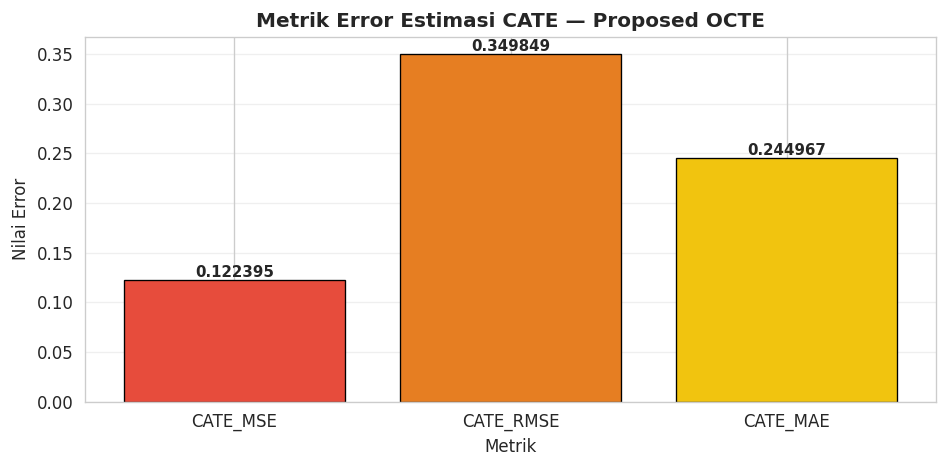

💾 Disimpan: /content/drive/MyDrive/last_experiment/figures/causal/causal_error_metrics.png


In [ ]:
print('='*55)
print('  📐 METRIK ERROR KAUSAL — OCTE')
print('='*55)
display(causal_df.set_index('Metric').rename(columns={'Value': 'Score'}))

# Bar chart metrik kausal
error_metrics = causal_df[causal_df['Metric'].isin(['CATE_MSE', 'CATE_RMSE', 'CATE_MAE'])]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c', '#e67e22', '#f1c40f']
bars = ax.bar(error_metrics['Metric'], error_metrics['Value'], color=colors, edgecolor='black', linewidth=0.8)

for bar, val in zip(bars, error_metrics['Value']):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.0001,
            f'{val:.6f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Metrik Error Estimasi CATE — Proposed OCTE', fontsize=12, fontweight='bold')
ax.set_ylabel('Nilai Error')
ax.set_xlabel('Metrik')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

FIG5 = f'{BASE_PATH}/figures/causal/causal_error_metrics.png'
plt.savefig(FIG5, dpi=300, bbox_inches='tight')
plt.show()
print(f'💾 Disimpan: {FIG5}')

---
## Cell 10 — Heterogenitas CATE Berdasarkan Status Treatment

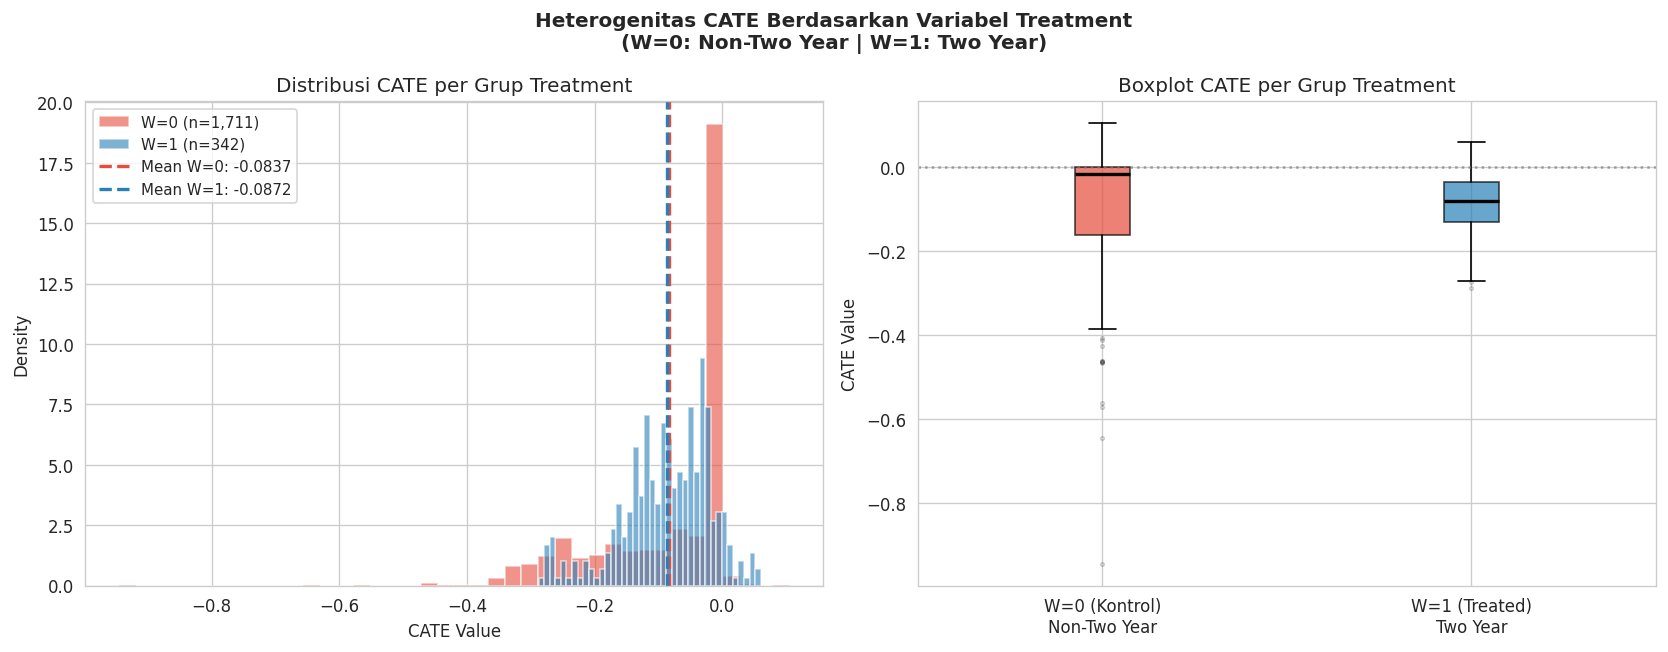

💾 Disimpan: /content/drive/MyDrive/last_experiment/figures/causal/cate_heterogeneity_by_treatment.png

📊 Statistik CATE per Grup:
   W=0 (Kontrol) — Mean: -0.0837, Std: 0.1119, Median: -0.0155
   W=1 (Treated) — Mean: -0.0872, Std: 0.0698, Median: -0.0804


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Heterogenitas CATE Berdasarkan Variabel Treatment\n(W=0: Non-Two Year | W=1: Two Year)',
             fontsize=12, fontweight='bold')

cate_w0 = cate_est[W_test == 0]
cate_w1 = cate_est[W_test == 1]

# Panel kiri: Histogram per group
axes[0].hist(cate_w0, bins=40, alpha=0.6, color='#e74c3c', label=f'W=0 (n={len(cate_w0):,})', density=True)
axes[0].hist(cate_w1, bins=40, alpha=0.6, color='#2980b9', label=f'W=1 (n={len(cate_w1):,})', density=True)
axes[0].axvline(cate_w0.mean(), color='#e74c3c', lw=2, linestyle='--', label=f'Mean W=0: {cate_w0.mean():.4f}')
axes[0].axvline(cate_w1.mean(), color='#2980b9', lw=2, linestyle='--', label=f'Mean W=1: {cate_w1.mean():.4f}')
axes[0].set_xlabel('CATE Value')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribusi CATE per Grup Treatment')
axes[0].legend(fontsize=9)

# Panel kanan: Boxplot per group
data_box = [cate_w0, cate_w1]
bp = axes[1].boxplot(data_box, vert=True, patch_artist=True,
                     boxprops=dict(alpha=0.7),
                     medianprops=dict(color='black', linewidth=2),
                     flierprops=dict(marker='o', alpha=0.2, markersize=2))
bp['boxes'][0].set_facecolor('#e74c3c')
bp['boxes'][1].set_facecolor('#2980b9')

axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['W=0 (Kontrol)\nNon-Two Year', 'W=1 (Treated)\nTwo Year'])
axes[1].set_ylabel('CATE Value')
axes[1].set_title('Boxplot CATE per Grup Treatment')
axes[1].axhline(0, color='gray', lw=1.5, linestyle=':', alpha=0.7)

plt.tight_layout()
FIG6 = f'{BASE_PATH}/figures/causal/cate_heterogeneity_by_treatment.png'
plt.savefig(FIG6, dpi=300, bbox_inches='tight')
plt.show()
print(f'💾 Disimpan: {FIG6}')
print(f'\n📊 Statistik CATE per Grup:')
print(f'   W=0 (Kontrol) — Mean: {cate_w0.mean():.4f}, Std: {cate_w0.std():.4f}, Median: {np.median(cate_w0):.4f}')
print(f'   W=1 (Treated) — Mean: {cate_w1.mean():.4f}, Std: {cate_w1.std():.4f}, Median: {np.median(cate_w1):.4f}')

---
## Cell 11 — Segmentasi Pelanggan Berdasarkan CATE
Membagi pelanggan ke dalam 3 segmen berdasarkan estimasi CATE untuk keperluan rekomendasi bisnis:
- **High Responders**: CATE sangat negatif → paling diuntungkan oleh kontrak panjang
- **Low Responders**: CATE netral → efek minimal
- **Adverse Responders**: CATE positif → kontrak panjang justru meningkatkan risiko churn

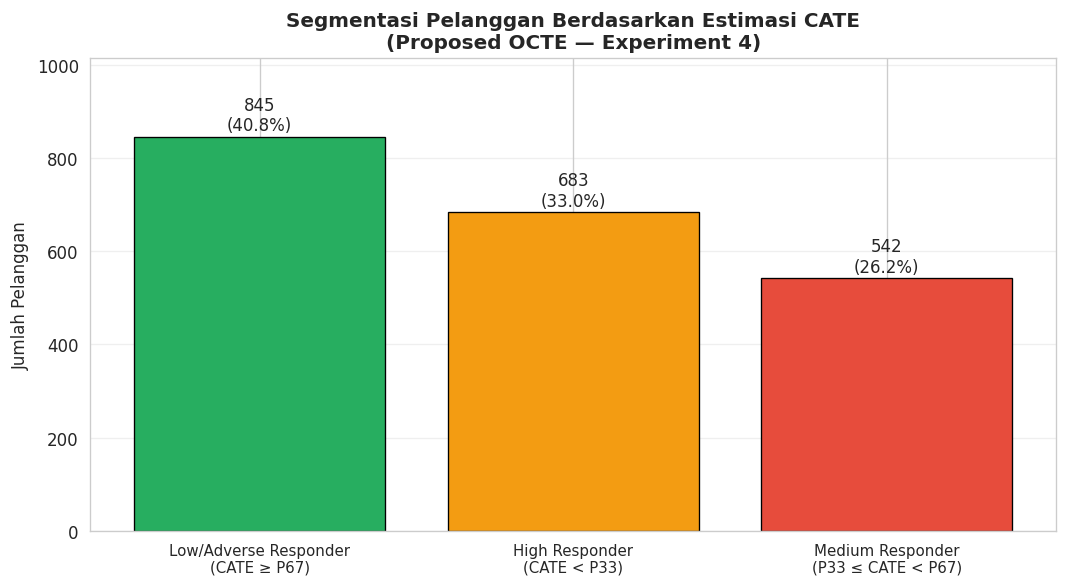

💾 Disimpan: /content/drive/MyDrive/last_experiment/figures/insights/customer_segmentation_cate.png

📋 Pembagian Segmen (threshold: P33=-0.1093, P67=0.0000):
   Low/Adverse Responder (CATE ≥ P67): 845 pelanggan (40.8%)
   High Responder (CATE < P33): 683 pelanggan (33.0%)
   Medium Responder (P33 ≤ CATE < P67): 542 pelanggan (26.2%)


In [ ]:
# Definisi segmen berdasarkan percentile CATE
p33 = np.percentile(cate_est, 33)
p67 = np.percentile(cate_est, 67)

def cate_segment(c):
    if c < p33:  return 'High Responder (CATE < P33)'
    elif c < p67: return 'Medium Responder (P33 ≤ CATE < P67)'
    else:         return 'Low/Adverse Responder (CATE ≥ P67)'

preds_df['CATE_Segment'] = [cate_segment(c) for c in cate_est]

seg_counts = preds_df['CATE_Segment'].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
colors_seg = ['#27ae60', '#f39c12', '#e74c3c']
bars = ax.bar(range(len(seg_counts)), seg_counts.values,
              color=colors_seg, edgecolor='black', linewidth=0.8)
for bar, count in zip(bars, seg_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            f'{count:,}\n({count/len(preds_df)*100:.1f}%)', ha='center', va='bottom', fontsize=10)

ax.set_xticks(range(len(seg_counts)))
ax.set_xticklabels([s.replace(' (', '\n(') for s in seg_counts.index], fontsize=9)
ax.set_ylabel('Jumlah Pelanggan')
ax.set_title('Segmentasi Pelanggan Berdasarkan Estimasi CATE\n(Proposed OCTE — Experiment 4)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, seg_counts.max() * 1.2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
FIG7 = f'{BASE_PATH}/figures/insights/customer_segmentation_cate.png'
plt.savefig(FIG7, dpi=300, bbox_inches='tight')
plt.show()
print(f'💾 Disimpan: {FIG7}')

print(f'\n📋 Pembagian Segmen (threshold: P33={p33:.4f}, P67={p67:.4f}):')
for seg, cnt in seg_counts.items():
    print(f'   {seg}: {cnt:,} pelanggan ({cnt/len(preds_df)*100:.1f}%)')

---
# BAGIAN C — INSIGHTS & FEATURE IMPORTANCE

---
## Cell 12 — Feature Importance RF vs Information Gain

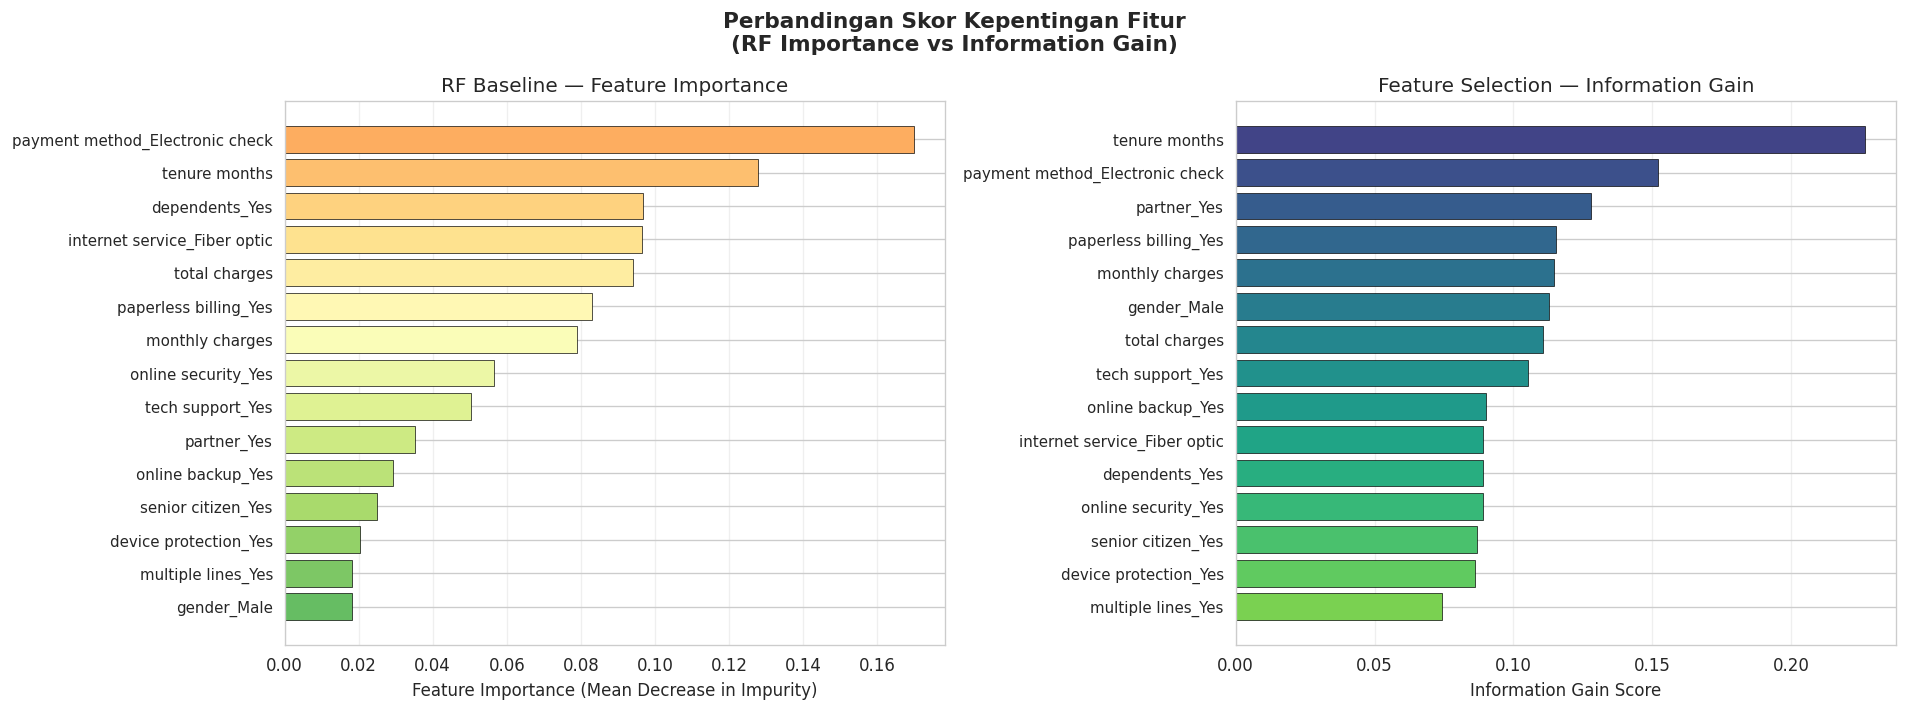

💾 Disimpan: /content/drive/MyDrive/last_experiment/figures/insights/feature_importance_comparison.png


In [ ]:
# Feature importance dari RF model
X_test_feat = X_test.drop(columns=['treatment_w'])
rf_importances = pd.DataFrame({
    'Feature': X_test_feat.columns,
    'RF_Importance': rf_model.feature_importances_
}).sort_values('RF_Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Perbandingan Skor Kepentingan Fitur\n(RF Importance vs Information Gain)',
             fontsize=13, fontweight='bold')

# Panel kiri: RF Feature Importance
top_rf = rf_importances.head(15)
colors_rf = plt.cm.RdYlGn(np.linspace(0.8, 0.3, 15))
axes[0].barh(range(15), top_rf['RF_Importance'].values[::-1], color=colors_rf, edgecolor='black', linewidth=0.4)
axes[0].set_yticks(range(15))
axes[0].set_yticklabels(top_rf['Feature'].values[::-1], fontsize=9)
axes[0].set_xlabel('Feature Importance (Mean Decrease in Impurity)')
axes[0].set_title('RF Baseline — Feature Importance')
axes[0].grid(axis='x', alpha=0.3)

# Panel kanan: Information Gain (dari Notebook 02)
top_ig = ig_df.head(15)
colors_ig = plt.cm.viridis(np.linspace(0.8, 0.2, 15))
axes[1].barh(range(15), top_ig['IG_Score'].values[::-1], color=colors_ig, edgecolor='black', linewidth=0.4)
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(top_ig['Feature'].values[::-1], fontsize=9)
axes[1].set_xlabel('Information Gain Score')
axes[1].set_title('Feature Selection — Information Gain')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
FIG8 = f'{BASE_PATH}/figures/insights/feature_importance_comparison.png'
plt.savefig(FIG8, dpi=300, bbox_inches='tight')
plt.show()
print(f'💾 Disimpan: {FIG8}')

---
## Cell 13 — CATE vs Probabilitas Churn (Scatter Plot)
Visualisasi hubungan antara probabilitas prediksi churn dan estimasi efek kausal per individu.

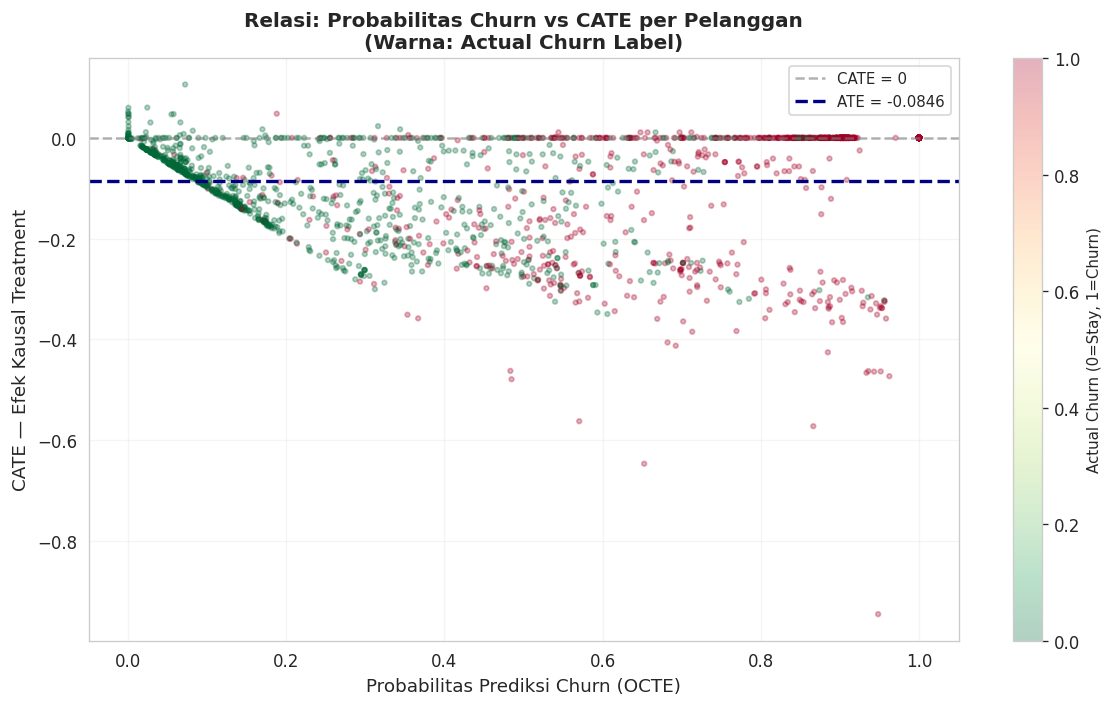

💾 Disimpan: /content/drive/MyDrive/last_experiment/figures/insights/cate_vs_churn_probability.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    octe_probs, cate_est,
    c=np.array(y_test), cmap='RdYlGn_r', alpha=0.3, s=8,
    vmin=0, vmax=1
)

ax.axhline(0, color='gray', lw=1.5, linestyle='--', alpha=0.6, label='CATE = 0')
ax.axhline(cate_est.mean(), color='navy', lw=2, linestyle='--',
           label=f'ATE = {cate_est.mean():.4f}')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Actual Churn (0=Stay, 1=Churn)', fontsize=9)

ax.set_xlabel('Probabilitas Prediksi Churn (OCTE)', fontsize=11)
ax.set_ylabel('CATE — Efek Kausal Treatment', fontsize=11)
ax.set_title('Relasi: Probabilitas Churn vs CATE per Pelanggan\n(Warna: Actual Churn Label)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
FIG9 = f'{BASE_PATH}/figures/insights/cate_vs_churn_probability.png'
plt.savefig(FIG9, dpi=300, bbox_inches='tight')
plt.show()
print(f'💾 Disimpan: {FIG9}')

---
## Cell 14 — Simpan Prediksi Final dengan Segmen ke Google Drive

In [ ]:
# Simpan prediksi final dengan informasi segmen
FINAL_PRED_PATH = f'{BASE_PATH}/results/predictions/final_predictions_with_segments.csv'
preds_df.to_csv(FINAL_PRED_PATH, index=False)

print('💾 Prediksi final + segmen berhasil disimpan:')
print(f'   → {FINAL_PRED_PATH}')
print(f'   Kolom: {preds_df.columns.tolist()}')
print(f'   Shape: {preds_df.shape}')

💾 Prediksi final + segmen berhasil disimpan:
   → /content/drive/MyDrive/last_experiment/results/predictions/final_predictions_with_segments.csv
   Kolom: ['Actual_Churn', 'W_Treatment', 'RF_Pred_Class', 'RF_Prob', 'OCTE_Pred_Class', 'OCTE_Prob', 'CATE_Estimate', 'CATE_Segment']
   Shape: (2070, 8)


---
## Cell 15 — Ringkasan Akhir Eksperimen 4
Dashboard ringkasan semua hasil eksperimen dalam satu output terstruktur.

In [ ]:
print('\n' + '█'*72)
print('  🏆 RINGKASAN AKHIR EKSPERIMEN 4 — SMOTE Before Split + OCTE')
print('█'*72)

print('\n📂 KONFIGURASI EKSPERIMEN:')
print(f'   Dataset              : Telco Customer Churn (IBM)')
print(f'   Balancing Strategy   : SMOTE Before Train-Test Split')
print(f'   Feature Selection    : Information Gain (Top-15)')
print(f'   Treatment Variable   : contract == "Two Year" → W=1')
print(f'   Causal Method        : Proposed OCTE (B={octe_model.B}, M={octe_model.M})')

print('\n📊 PERFORMA KLASIFIKASI:')
display(metrics_df)

print('\n📐 ESTIMASI KAUSAL (CATE):')
print(f'   ATE (Average Treatment Effect) : {cate_est.mean():.4f}')
print(f'   Std CATE                       : {cate_est.std():.4f}')
print(f'   CATE MSE                       : {causal_df.loc[causal_df["Metric"]=="CATE_MSE", "Value"].values[0]:.6f}')
print(f'   CATE RMSE                      : {causal_df.loc[causal_df["Metric"]=="CATE_RMSE", "Value"].values[0]:.6f}')

print('\n🧩 SEGMENTASI PELANGGAN (BERDASARKAN CATE):')
for seg, cnt in preds_df['CATE_Segment'].value_counts().items():
    print(f'   {seg}: {cnt:,} ({cnt/len(preds_df)*100:.1f}%)')

print('\n📁 ARTEFAK TERSIMPAN DI GOOGLE DRIVE:')
print(f'   data/processed/         → Dataset bersih, train/test split')
print(f'   results/metrics/        → Metrik klasifikasi & kausal')
print(f'   results/models/         → Model OCTE & RF (.pkl)')
print(f'   results/predictions/    → Prediksi + estimasi CATE')
print(f'   figures/                → Semua visualisasi (.png, 300 DPI)')
print('\n' + '█'*72)
print('  ✅ Eksperimen 4 selesai sepenuhnya.')
print('█'*72)


████████████████████████████████████████████████████████████████████████
  🏆 RINGKASAN AKHIR EKSPERIMEN 4 — SMOTE Before Split + OCTE
████████████████████████████████████████████████████████████████████████

📂 KONFIGURASI EKSPERIMEN:
   Dataset              : Telco Customer Churn (IBM)
   Balancing Strategy   : SMOTE Before Train-Test Split
   Feature Selection    : Information Gain (Top-15)
   Treatment Variable   : contract == "Two Year" → W=1
   Causal Method        : Proposed OCTE (B=150, M=40)

📊 PERFORMA KLASIFIKASI:


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Random Forest Baseline,86.23%,85.58%,87.15%,86.36%,94.01%
1,Proposed OCTE,85.65%,84.81%,86.86%,85.82%,93.05%



📐 ESTIMASI KAUSAL (CATE):
   ATE (Average Treatment Effect) : -0.0846
   Std CATE                       : 0.1067
   CATE MSE                       : 0.122395
   CATE RMSE                      : 0.349849

🧩 SEGMENTASI PELANGGAN (BERDASARKAN CATE):
   Low/Adverse Responder (CATE ≥ P67): 845 (40.8%)
   High Responder (CATE < P33): 683 (33.0%)
   Medium Responder (P33 ≤ CATE < P67): 542 (26.2%)

📁 ARTEFAK TERSIMPAN DI GOOGLE DRIVE:
   data/processed/         → Dataset bersih, train/test split
   results/metrics/        → Metrik klasifikasi & kausal
   results/models/         → Model OCTE & RF (.pkl)
   results/predictions/    → Prediksi + estimasi CATE
   figures/                → Semua visualisasi (.png, 300 DPI)

████████████████████████████████████████████████████████████████████████
  ✅ Eksperimen 4 selesai sepenuhnya.
████████████████████████████████████████████████████████████████████████


---

## Cell 16 — Rekomendasi Keputusan Bisnis

Berdasarkan analisis klasifikasi dan kausal dari Eksperimen 4, berikut adalah rekomendasi keputusan bisnis yang dapat diambil:

### 1. Fokus pada Pelanggan 'High Responder' untuk Penawaran Kontrak Dua Tahun
- **Identifikasi**: Pelanggan dalam segmen 'High Responder' (CATE < P33) memiliki probabilitas churn yang **sangat menurun** ketika ditawarkan kontrak dua tahun.
- **Aksi**: Prioritaskan penawaran kontrak 'Two Year' kepada segmen ini. Kampanye retensi yang menargetkan kelompok ini kemungkinan besar akan paling efektif dan memberikan ROI terbaik.
- **Contoh**: Gunakan fitur-fitur seperti 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', dan 'StreamingMovies' (jika berkorelasi dengan High Responders) untuk personalisasi penawaran.

### 2. Evaluasi Ulang Penawaran untuk 'Low/Adverse Responder'
- **Identifikasi**: Pelanggan dalam segmen 'Low/Adverse Responder' (CATE ≥ P67) menunjukkan efek kausal yang netral atau bahkan positif (artinya kontrak dua tahun justru **meningkatkan** probabilitas churn).
- **Aksi**: Hindari secara otomatis menawarkan kontrak 'Two Year' kepada segmen ini. Pertimbangkan strategi retensi alternatif atau penawaran produk yang berbeda yang tidak melibatkan kontrak jangka panjang.
- **Contoh**: Untuk segmen ini, fokus pada peningkatan kualitas layanan, diskon sementara, atau penawaran fleksibel tanpa ikatan kontrak.

### 3. Monitoring dan Personalisasi Berbasis 'Medium Responder'
- **Identifikasi**: Segmen 'Medium Responder' (P33 ≤ CATE < P67) menunjukkan efek kausal yang moderat atau sedikit negatif.
- **Aksi**: Segmen ini mungkin memerlukan pendekatan yang lebih personal. Lakukan A/B testing atau kampanye pilot dengan penawaran kontrak 'Two Year' yang disesuaikan (misalnya, dengan bonus tambahan atau fleksibilitas tertentu) untuk mengukur respons.

### 4. Optimalisasi Fitur Penting
- **Identifikasi**: Fitur-fitur seperti 'TotalCharges', 'MonthlyCharges', 'tenure', 'PaperlessBilling', dan 'PaymentMethod' memiliki pengaruh signifikan terhadap churn.
- **Aksi**: Gunakan insight ini untuk mengembangkan program retensi. Misalnya, tawarkan diskon progresif berdasarkan 'tenure', promosikan 'PaperlessBilling' untuk mengurangi biaya operasional dan meningkatkan kepuasan, serta optimalkan opsi 'PaymentMethod' yang paling disukai pelanggan.

### 5. Pemanfaatan Model OCTE untuk Presisi Intervensi
- **Identifikasi**: Model OCTE memberikan estimasi CATE yang individual, memungkinkan intervensi yang sangat spesifik.
- **Aksi**: Integrasikan output `CATE_Estimate` dan `CATE_Segment` dari model OCTE ke dalam sistem CRM atau platform marketing. Ini akan memungkinkan tim penjualan atau marketing untuk melakukan mikro-segmentasi dan menargetkan pelanggan dengan penawaran yang paling relevan, bukan pendekatan 'one-size-fits-all'.